In [52]:
library(torch)
library(luz)
#library(lecospectR)

In [53]:
source("./Functions/lecospectR.R")

In [54]:
net <- nn_module(
    "jigsaw",
     initialize = function(num_components = NUM_VARS, num_levels = 8) {
      self$internal_dimension <- 512
      



      #C block
      self$net <- nn_sequential(
        nn_flatten(start_dim = 2,end_dim = -1),
        nn_linear(
          in_features = 600,
          out_features = self$internal_dimension
        ),
        nn_relu(),
        nn_dropout(p = 0.3),
        nn_linear(
          in_features = self$internal_dimension, 
          out_features = self$internal_dimension
        ),
        nn_dropout(p = 0.3),
        nn_relu(),
             nn_linear(
          in_features = self$internal_dimension, 
          out_features = self$internal_dimension
        ),
        nn_dropout(p = 0.3),
        nn_relu(),
             nn_linear(
          in_features = self$internal_dimension, 
          out_features = self$internal_dimension
        ),
        nn_dropout(p = 0.3),
        nn_relu(),
        nn_linear(
          in_features = self$internal_dimension, 
          out_features = self$internal_dimension
        ),
        nn_dropout(p = 0.3),
             
        nn_relu(),
        nn_linear(
          in_features = self$internal_dimension, 
          out_features = self$internal_dimension
        ),
        nn_dropout(p = 0.3),
             
        nn_relu(),
        nn_linear(
          in_features = self$internal_dimension, 
          out_features = self$internal_dimension
        ),
        nn_dropout(p = 0.3),
        
        nn_relu(),
        nn_linear(
          in_features = self$internal_dimension, 
          out_features = self$internal_dimension
        ),
        nn_dropout(p = 0.3),
        
        nn_relu(),
        nn_linear(
          in_features = self$internal_dimension, 
          out_features = self$internal_dimension
        ),
        nn_dropout(p = 0.3),
        
        nn_relu(),
        nn_linear(
          in_features = self$internal_dimension, 
          out_features = self$internal_dimension
        ),
        nn_dropout(p = 0.3),
            nn_relu(),
        nn_linear(
          in_features = self$internal_dimension, 
          out_features = self$internal_dimension
        ),
        nn_dropout(p = 0.3),

            nn_relu(),
        nn_linear(
          in_features = self$internal_dimension, 
          out_features = self$internal_dimension
        ),
        nn_dropout(p = 0.3),

            nn_relu(),
        nn_linear(
          in_features = self$internal_dimension, 
          out_features = self$internal_dimension
        ),
        nn_dropout(p = 0.3),

            nn_relu(),
        nn_linear(
          in_features = self$internal_dimension, 
          out_features = self$internal_dimension
        ),
        nn_dropout(p = 0.3),
        
        nn_relu(),
        nn_linear(
          in_features = self$internal_dimension, 
          out_features = self$internal_dimension
        ),
        nn_dropout(p = 0.3),
        
        nn_relu(),
        nn_linear(
          in_features = self$internal_dimension,
          out_features = self$internal_dimension
        ),
        nn_dropout(p = 0.3),
                
        nn_relu(),
        nn_linear(
          in_features = self$internal_dimension,
          out_features = self$internal_dimension
        ),
        nn_dropout(p = 0.3),
                
        nn_relu(),
        nn_linear(
          in_features = self$internal_dimension,
          out_features = self$internal_dimension
        ),
        nn_dropout(p = 0.3),
                
        nn_relu(),
        nn_linear(
          in_features = self$internal_dimension,
          out_features = self$internal_dimension
        ),
        nn_dropout(p = 0.3),
                
        nn_relu(),
        nn_linear(
          in_features = self$internal_dimension,
          out_features = self$internal_dimension
        ),
        nn_dropout(p = 0.3),
                
        nn_relu(),
        nn_linear(
          in_features = self$internal_dimension,
          out_features = self$internal_dimension
        ),
        nn_dropout(p = 0.3),
                
        nn_relu(),
        nn_linear(
          in_features = self$internal_dimension,
          out_features = self$internal_dimension
        ),
        nn_dropout(p = 0.3),
                
        nn_relu(),
        nn_linear(
          in_features = self$internal_dimension,
          out_features = self$internal_dimension
        ),
        nn_dropout(p = 0.3),
                
        nn_relu(),
        nn_linear(
          in_features = self$internal_dimension,
          out_features = self$internal_dimension
        ),
        nn_dropout(p = 0.3),
        
        nn_relu(),
        nn_linear(
          in_features = self$internal_dimension,
          out_features = 8
        )
      )
  },

  forward = function(x) {
    return(self$net(x))
  }
)

In [55]:
add_channel_dim <- function(img) {
   x <- img$unsqueeze(1)
   return(torch_transpose(x, 1,2))
}

In [56]:
create_variable_names <- function(start, stop){
    names <- c()
    for(i in start:stop){
        names <- append(
            names, 
            paste0("X", i))
    }

    return(names)
}

In [57]:
independent_variables <- create_variable_names(400L, 999L)

dependent_variable <- "FncGrp1" 
NUM_VARS <- length(independent_variables)
print(length(independent_variables))

[1] 600


In [58]:
# define the dataset
data_df <- read.csv(
    file = "Data/Ground_Validation/PFT_image_spectra/PFT_Image_SpectralLib_Clean.csv"
    )


In [59]:

lecospec_dataset <- torch::dataset(
    name = "lecospec_image",
    initialize = function(df, transform = function(x){x}) {
        self$x <- as.matrix(
            #cbind(
                df[, independent_variables]
               # get_vegetation_indices(df = df, ml_model = NULL) %>%
                #    clip_outliers()
            #)
        )
        
        self$y <- torch_tensor(
            as.matrix(
                as.integer(
                    as.factor(
                        df[, dependent_variable]
                        )
                    )
                )
            )
        self$transform <- transform
    },

    .getitem = function(i) {
        list(
            x = self$transform(torch_flatten(self$x[i,])),
            y = torch_flatten(self$y[i])$squeeze()
        )
    },

    .length = function() {
        self$y$size()[[1]]
    }
)

In [60]:
head(data_df)

,X,UID,ScanNum,sample_name,PFT,FncGrp1,Site,X398,X399,X400,⋯,X990,X991,X992,X993,X994,X995,X996,X997,X998,X999
,<int>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,1,BisonGulchPFTsBetula1,1,spec_1,Betula,ShrubDecid,BisonGulch,0.05814769,0.05926529,0.06028869,⋯,0.6815182,0.6811660,0.6890470,0.7040298,0.7249807,0.7507566,0.7801884,0.8121027,0.8453261,0.8786852
2,2,BisonGulchPFTsBetula1,1,spec_2,Betula,ShrubDecid,BisonGulch,0.04456014,0.04778814,0.05079318,⋯,0.6706666,0.6683159,0.6786394,0.7000307,0.7308801,0.7695067,0.8140391,0.8625739,0.9132079,0.9640378
3,3,BisonGulchPFTsBetula1,1,spec_3,Betula,ShrubDecid,BisonGulch,0.03929324,0.04265593,0.04557066,⋯,0.5152525,0.5091915,0.5178217,0.5395294,0.5726982,0.6156166,0.6663192,0.7227978,0.7830447,0.8450520
4,4,BisonGulchPFTsBetula1,1,spec_4,Betula,ShrubDecid,BisonGulch,0.13230228,0.11122692,0.09129034,⋯,0.5120581,0.5113880,0.5348292,0.5745538,0.6227243,0.6723311,0.7185860,0.7570701,0.7833644,0.7930498
5,5,BisonGulchPFTsBetula1,1,spec_5,Betula,ShrubDecid,BisonGulch,0.05211388,0.05565497,0.05878525,⋯,0.6863419,0.6680365,0.6509006,0.6344450,0.6181806,0.6017555,0.5851848,0.5685449,0.5519121,0.5353626
6,6,BisonGulchPFTsBetula1,1,spec_6,Betula,ShrubDecid,BisonGulch,0.06955397,0.06788242,0.06631141,⋯,0.7354495,0.7371508,0.7445194,0.7567953,0.7732173,0.7930235,0.8154512,0.8397375,0.8651196,0.8908347


In [61]:
num_per_pft <- 300
train_test_data <- create_patch_balanced_sample(
    data_df,
    test_count = 20,
    train_count = NULL,
    verbose = FALSE
    )

split_2_train <- create_patch_balanced_sample(
    train_test_data$remainder,
    test_count = num_per_pft,
    train_count = 2000,
    verbose = FALSE
    )

In [62]:
print(names(split_2_train))

[1] "selection"         "remainder"         "samples_per_patch"
[4] "samples_per_class"


In [63]:
print(split_2_train$selection)

      X                   UID ScanNum sample_name    PFT        FncGrp1
3     3 BisonGulchPFTsBetula1       1      spec_3 Betula     ShrubDecid
22   22 BisonGulchPFTsBetula1       1     spec_22 Betula     ShrubDecid
4     4 BisonGulchPFTsBetula1       1      spec_4 Betula     ShrubDecid
23   23 BisonGulchPFTsBetula1       1     spec_23 Betula     ShrubDecid
19   19 BisonGulchPFTsBetula1       1     spec_19 Betula     ShrubDecid
5     5 BisonGulchPFTsBetula1       1      spec_5 Betula     ShrubDecid
2     2 BisonGulchPFTsBetula1       1      spec_2 Betula     ShrubDecid
18   18 BisonGulchPFTsBetula1       1     spec_18 Betula     ShrubDecid
6     6 BisonGulchPFTsBetula1       1      spec_6 Betula     ShrubDecid
9     9 BisonGulchPFTsBetula1       1      spec_9 Betula     ShrubDecid
1     1 BisonGulchPFTsBetula1       1      spec_1 Betula     ShrubDecid
24   24 BisonGulchPFTsBetula1       1     spec_24 Betula     ShrubDecid
26   26 BisonGulchPFTsBetula2       2      spec_1 Betula     Shr

In [64]:
train_indices <- sample(1:nrow(data_df), 250)
train_ds <- lecospec_dataset(
    split_2_train$selection,
    transform = add_channel_dim
    )
valid_ds <- lecospec_dataset(
    train_test_data$selection, 
    transform = add_channel_dim
    )

length(train_ds)
length(valid_ds)

[1] 2222

[1] 160

In [65]:
# create a dataloader
test_dl <- torch::dataloader(
    valid_ds,
    batch_size = 80,
    shuffle = FALSE
)

train_dl <- torch::dataloader(
    train_ds,
    batch_size = 240,
    shuffle = TRUE
)

In [66]:
batch <- dataloader_make_iter(train_dl) %>% dataloader_next()
print(dim(batch$x))
print(dim(batch$y))

[1] 240  95   1
[1] 240


In [67]:
print(batch$x$shape)

[1] 240  95   1


In [68]:
print(batch$y$shape)

[1] 240


In [69]:
model <- net()
model(batch$x)


torch_tensor
0.01 *
 5.7342 -1.1767  3.3387  4.5054  0.2009 -1.2801  0.5506  0.5048
  5.1457 -2.3526  5.0671  4.8117 -0.0336  0.3315  1.8085  1.2478
  5.5624 -1.6541  4.0390  3.3530  1.2918 -1.7220  1.6577  0.2496
  5.3743 -1.9798  3.8568  3.7392  1.6618 -1.0992  1.4039  3.3220
  4.1325 -1.4043  3.8541  3.9073  0.5637 -2.2676  1.8345  2.4220
  4.9187 -1.5621  4.5288  5.9376  1.9103 -1.8505  1.0294  1.4507
  5.2738 -1.1667  5.6371  5.6279  2.1640 -1.4270  3.0974 -0.5742
  4.6223 -2.4057  2.7207  5.6281  1.4883 -0.7032 -1.1110  0.1754
  4.9716 -0.6932  5.7370  4.9408  1.0854 -1.1248  2.6827  2.2168
  5.5510 -1.1316  5.2428  4.4353  0.9838 -3.6060  2.4008  0.9451
  4.3481 -0.4878  3.1973  4.9511  0.1962 -0.4154  2.6164  2.0411
  4.5067 -1.2196  4.2496  4.1634  1.4571 -2.7500  0.9373  0.2339
  5.4186 -1.8396  5.3003  4.8660 -0.5574 -2.0946  2.3599  0.6352
  5.3740 -1.6613  4.5604  5.6045  1.3820 -0.5475  1.2999 -0.9202
  6.1477 -2.2506  4.5956  4.6946 -0.7475 -2.2728  2.2479  2.1758
  5.22

In [70]:
batch$y

torch_tensor
 3
 8
 1
 5
 1
 4
 4
 5
 1
 5
 8
 6
 5
 2
 7
 3
 8
 3
 3
 7
 2
 1
 7
 4
 4
 5
 6
 4
 6
 5
... [the output was truncated (use n=-1 to disable)]
[ CPULongType{240} ]

In [71]:
print_callback <- luz_callback(
  name = "print_callback",
  initialize = function(message) {
    self$message <- message
  },
  on_train_batch_end = function() {
    cat("Iteration ", ctx$iter, "\n")
  },
  on_epoch_end = function() {
    cat(self$message, "\n")
  }
)

In [72]:
net_fitted <- net %>%
  setup(
    loss = nn_cross_entropy_loss(),
    optimizer = optim_adam,
    metrics = list(
      luz_metric_accuracy()
    )
  ) %>%
  set_opt_hparams(lr = 0.001) %>% 
  fit(
    train_dl, 
    epochs = 500, 
    valid_data = test_dl,
    callbacks = list(
      print_callback("Training Complete")
    )
    )

In [ ]:
net_fitted

A `luz_module_fitted`
── Time ────────────────────────────────────────────────────────────────────────
• Total time: 4h 18m 31.6s
• Avg time per training epoch: 15s

── Results ─────────────────────────────────────────────────────────────────────
Metrics observed in the last epoch.

ℹ Training:
loss: 2.0515
acc: 0.1206

── Model ───────────────────────────────────────────────────────────────────────
An `nn_module` containing 6,094,344 parameters.

── Modules ─────────────────────────────────────────────────────────────────────
• net: <nn_sequential> #6,094,344 parameters

In [ ]:
predict(net_fitted,newdata = batch$x)

torch_tensor
0.01 *
 9.0337  8.5180  8.0316  9.4665  7.0718 -86.3385  9.3777  7.9552
  9.0337  8.5180  8.0316  9.4665  7.0718 -86.3385  9.3777  7.9552
  9.0337  8.5180  8.0316  9.4665  7.0718 -86.3385  9.3777  7.9552
  9.0337  8.5180  8.0316  9.4665  7.0718 -86.3385  9.3777  7.9552
  9.0337  8.5180  8.0316  9.4665  7.0718 -86.3385  9.3777  7.9552
  9.0337  8.5180  8.0316  9.4665  7.0718 -86.3385  9.3777  7.9552
  9.0337  8.5180  8.0316  9.4665  7.0718 -86.3385  9.3777  7.9552
  9.0337  8.5180  8.0316  9.4665  7.0718 -86.3385  9.3777  7.9552
  9.0337  8.5180  8.0316  9.4665  7.0718 -86.3385  9.3777  7.9552
  9.0337  8.5180  8.0316  9.4665  7.0718 -86.3385  9.3777  7.9552
  9.0337  8.5180  8.0316  9.4665  7.0718 -86.3385  9.3777  7.9552
  9.0337  8.5180  8.0316  9.4665  7.0718 -86.3385  9.3777  7.9552
  9.0337  8.5180  8.0316  9.4665  7.0718 -86.3385  9.3777  7.9552
  9.0337  8.5180  8.0316  9.4665  7.0718 -86.3385  9.3777  7.9552
  9.0337  8.5180  8.0316  9.4665  7.0718 -86.3385  9.3777

## Next

Need to define the correct nueral net architecture, and then the training loop should work as intended.  This is likely some kind of U-Net from a paper.  

Just a matter of finding the correct one and plugging the layers into the model above.  

Hopefully that works directly

In [ ]:
preds <- predict(net_fitted, test_dl)

torch_tensor
0.01 *
 9.0337  8.5180  8.0316  9.4665  7.0718 -86.3385  9.3777  7.9552
  9.0337  8.5180  8.0316  9.4665  7.0718 -86.3385  9.3777  7.9552
  9.0337  8.5180  8.0316  9.4665  7.0718 -86.3385  9.3777  7.9552
  9.0337  8.5180  8.0316  9.4665  7.0718 -86.3385  9.3777  7.9552
  9.0337  8.5180  8.0316  9.4665  7.0718 -86.3385  9.3777  7.9552
  9.0337  8.5180  8.0316  9.4665  7.0718 -86.3385  9.3777  7.9552
  9.0337  8.5180  8.0316  9.4665  7.0718 -86.3385  9.3777  7.9552
  9.0337  8.5180  8.0316  9.4665  7.0718 -86.3385  9.3777  7.9552
  9.0337  8.5180  8.0316  9.4665  7.0718 -86.3385  9.3777  7.9552
  9.0337  8.5180  8.0316  9.4665  7.0718 -86.3385  9.3777  7.9552
  9.0337  8.5180  8.0316  9.4665  7.0718 -86.3385  9.3777  7.9552
  9.0337  8.5180  8.0316  9.4665  7.0718 -86.3385  9.3777  7.9552
  9.0337  8.5180  8.0316  9.4665  7.0718 -86.3385  9.3777  7.9552
  9.0337  8.5180  8.0316  9.4665  7.0718 -86.3385  9.3777  7.9552
  9.0337  8.5180  8.0316  9.4665  7.0718 -86.3385  9.3777

List of 138
 $ line                            :List of 6
  ..$ colour       : chr "black"
  ..$ linewidth    : num 0.5
  ..$ linetype     : num 1
  ..$ lineend      : chr "butt"
  ..$ arrow        : logi FALSE
  ..$ inherit.blank: logi TRUE
  ..- attr(*, "class")= chr [1:2] "element_line" "element"
 $ rect                            :List of 5
  ..$ fill         : chr "white"
  ..$ colour       : chr "black"
  ..$ linewidth    : num 0.5
  ..$ linetype     : num 1
  ..$ inherit.blank: logi TRUE
  ..- attr(*, "class")= chr [1:2] "element_rect" "element"
 $ text                            :List of 11
  ..$ family       : chr ""
  ..$ face         : chr "plain"
  ..$ colour       : chr "black"
  ..$ size         : num 11
  ..$ hjust        : num 0.5
  ..$ vjust        : num 0.5
  ..$ angle        : num 0
  ..$ lineheight   : num 0.9
  ..$ margin       : 'margin' num [1:4] 0points 0points 0points 0points
  .. ..- attr(*, "unit")= int 8
  ..$ debug        : logi FALSE
  ..$ inherit.blank: l

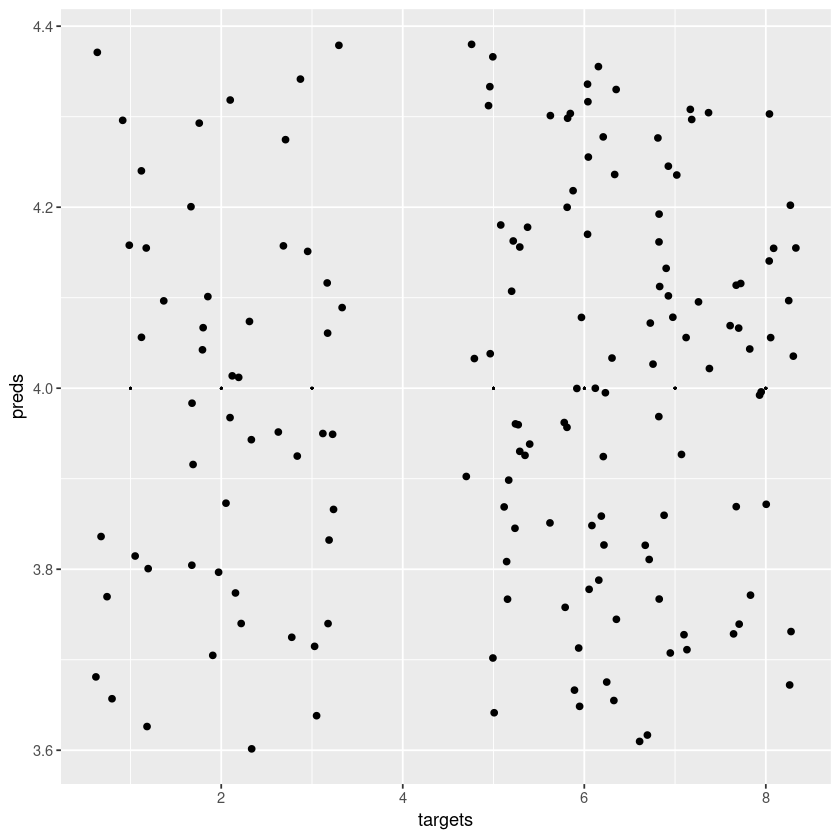

In [ ]:
#test_dl <- dataloader(valid_ds, batch_size = 5000)
targets <- (test_dl %>% dataloader_make_iter() %>% dataloader_next())$y %>% as.numeric()

y_pred <- torch_argmax(preds, dim = 2) %>% as.numeric()
df <- data.frame(preds = y_pred, targets = targets)
#library(ggplot2)

print(preds)


ggplot(df, aes(x = targets, y = preds)) +
  geom_point(size = 0.1) +
  geom_jitter()
  theme_classic() +
  xlab("true correlations") +
  ylab("model predictions")

#plot(y_pred, targets)


In [ ]:
df$preds %>% as.factor() %>% levels()

[1] "4"

In [ ]:
df$targets %>% as.factor() %>% levels()

[1] "1" "2" "3" "5" "6" "7" "8"

In [ ]:
target_f <- df$targets %>% as.factor()
levels(target_f) <- c(levels(target_f), '4')

In [ ]:
results_cm <- caret::confusionMatrix(
    df$preds %>% as.factor(),
    target_f
)

write(
    rjson::toJSON(results_cm), 
    file = "./linear_results_confusion_bands_only.json"
    )

Warning message in confusionMatrix.default(df$preds %>% as.factor(), target_f):
“Levels are not in the same order for reference and data. Refactoring data to match.”


In [ ]:
luz_save(obj = net_fitted,path = "./dl_linear_v2_512_bands.dat")